# Robust Color Compression with KMeans Clustering

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
import cv2

## Preprocess Image

In [33]:
image = cv2.imread(r"image-from-rawpixel-id-16848319-jpeg.jpg") # Importing image
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB) # converting image from BGR to RGB color

In [152]:
shape = image.shape # Getting the original shape of the image
print("Shape of the original image:",shape)

Shape of the original image: (1201, 673, 3)


In [35]:
colorArrayImage = image.reshape(shape[0]*shape[1],shape[2]) # converting image to color array that contains only array of a single color contains 3 values i.r. RBG

In [151]:
# finding the number of unique colors in the image
uniqueColorCount = np.unique(colorArrayImage,axis=0).shape[0]
print("Number of unique colors in image:",uniqueColorCount)

Number of unique colors in image: 190789


## K-Means Clusturing for color compression

In [131]:
k = 8 # Number of colors present in converted image (Change as per requirement)

In [132]:
kmeans = KMeans(k) # model creating with KMeans algorithm
kmeans.fit(colorArrayImage) # Model Training with flatten color array

KMeans()

In [150]:
labels = kmeans.labels_ # checking the labels of the dominant colors of the image
print("Labels of cluster:\n",labels)

Labels of cluster:
 [4 4 4 ... 7 7 7]


In [147]:
center_values = cluster_centers = kmeans.cluster_centers_ # finding the central point of the cluster or domainat color of the image (Number of dominant colors or Central points of cluster = K)
print("Dominating color values (RGB):\n",center_values)

Dominating color values (RGB):
 [[ 58.87997724  59.37162159  31.27501344]
 [248.29409386 196.85631477 129.09584632]
 [219.61395856 123.89237115  24.23917785]
 [128.9735432   83.65733226  27.55096561]
 [253.23222555 246.60795065 214.13476487]
 [181.80903936 126.04790862 101.97373654]
 [107.7817075   92.56291111  86.00243773]
 [ 16.61584433  25.10809702  13.73944161]]


## Converting the image to compressed image uisng KMeans Clustering

In [135]:
def predict(x):  # creating map function to replace the color of the image to the classified dominant color of the image 
    x = [x]
    label = kmeans.predict(x)[0] # label prediction of the colors
    colorValues = center_values[label] # Selection of the dominant color using label
    return list(colorValues) # return the dominant color

In [136]:
convertedImage = list(map(predict,colorArrayImage))

In [137]:
convertedImage = np.array(convertedImage,dtype=np.uint8) # Applying map function to create flatten image

In [144]:
convertedImageShape = convertedImage.shape # Checking the shpae of converted Flatten image
print("Converted Iamge shape (Flatten): ",convertedImageShape)

Converted Iamge shape (Flatten) (808273, 3)


In [139]:
finalImage = convertedImage.reshape(shape) # converting flattend image to 2d image 

In [140]:
finalImage = np.round(finalImage) # Rounding off the values of converted image from float to int

In [153]:
convertedImageUniqueColors = np.unique(finalImage.reshape(shape[0]*shape[1],-1),axis=0).shape[0] # finding the number of unique colors in the converted image
print("Number of unique colors in converted image: ",convertedImageUniqueColors)

Number of unique colors in converted image:  8


## Drafting the Images Side by Side

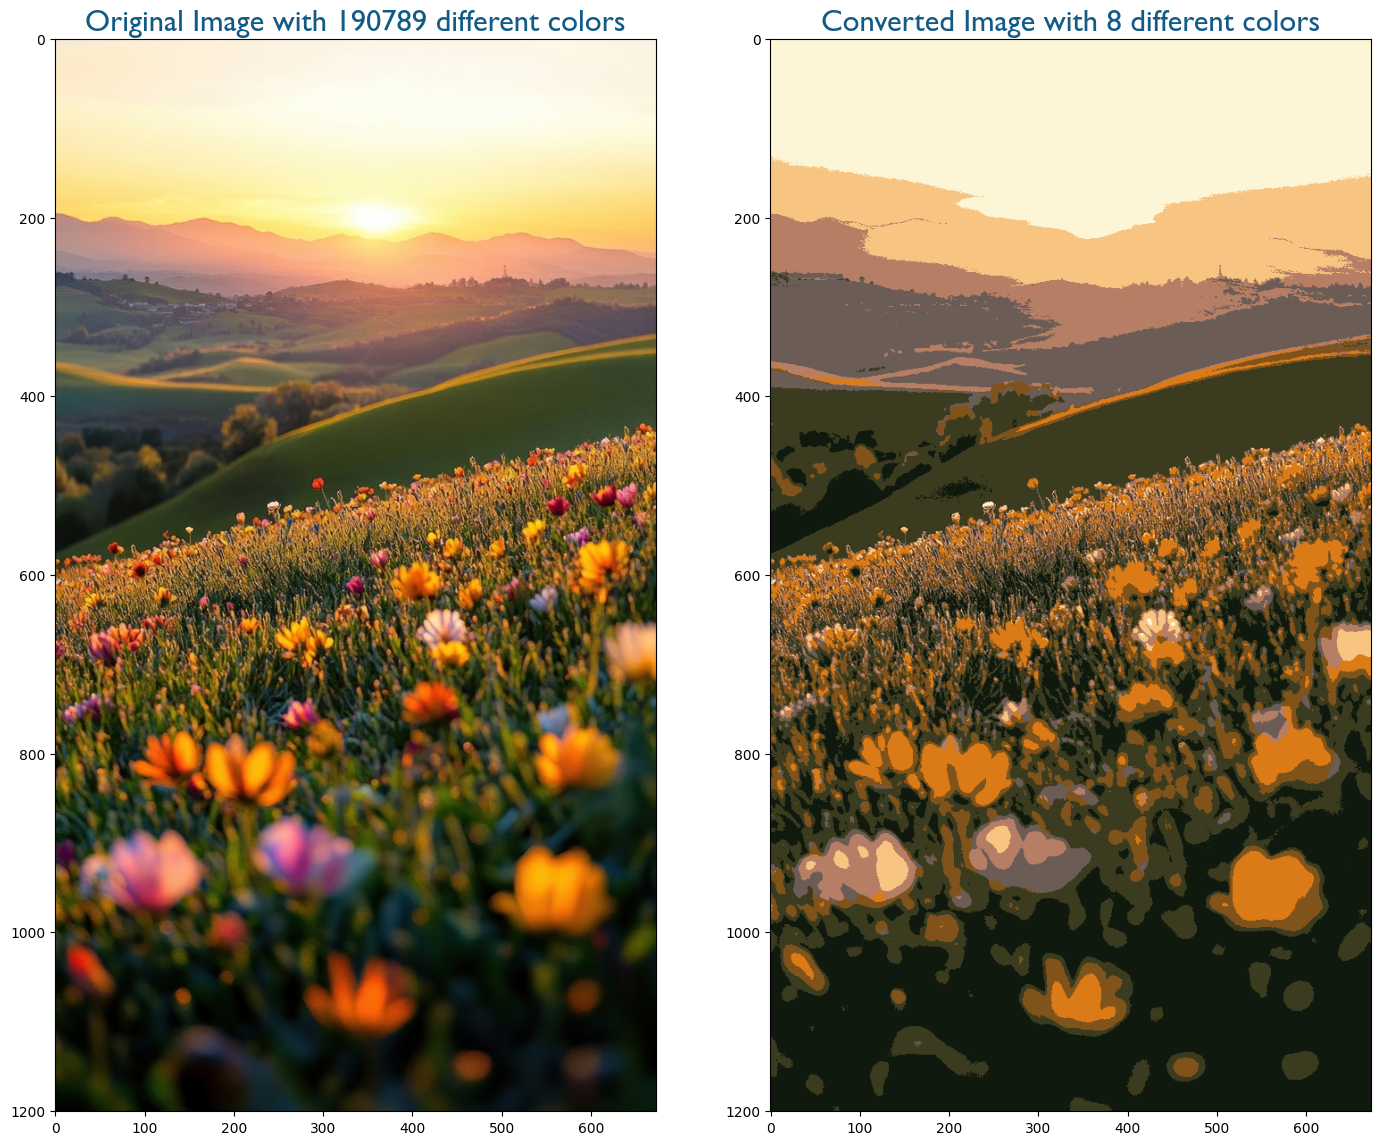

In [141]:
# Plotting original image and converted image side by side
fig, axes = plt.subplots(1,2,figsize=(15,15))
axes[0].imshow(image)
axes[0].set_title(f"Original Image with {uniqueColorCount} different colors",fontname="Gill Sans MT",color="#135b87",fontsize=22)
axes[1].imshow(finalImage)
axes[1].set_title(f"Converted Image with {k} different colors",fontname="Gill Sans MT",color="#135b87",fontsize=22)
plt.tight_layout(pad=5)
plt.show() 


In [143]:
fig.savefig(f"{k}.png",dpi=500) # Saving the plotted image to memory

# End